# CHURN MODELING USING ANN

#### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

#### Loading the data

In [2]:
df=pd.read_csv('../data/Churn_Modelling.csv')

#### First view of data

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

<Axes: >

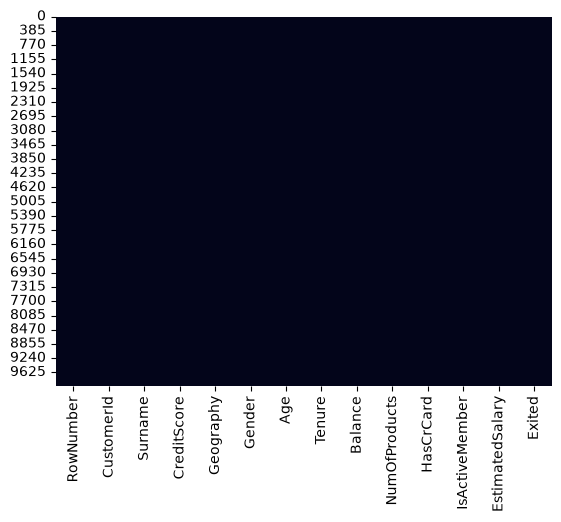

In [6]:
sns.heatmap(df.isna(),cbar=False)

In [7]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [10]:
le_gen=LabelEncoder()
df['Gender']=le_gen.fit_transform(df['Gender'])

In [11]:
df['Gender'].unique()

array([0, 1])

In [12]:
df['Geography'].unique()

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [13]:
#OneHotEncoding on Geographical Column
from sklearn.preprocessing import OneHotEncoder
oneHot_geo=OneHotEncoder()

In [14]:
geo_enc=oneHot_geo.fit_transform(df[['Geography']])

In [15]:
geo_enc.toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(10000, 3))

In [16]:
oneHot_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [17]:
encoded_df=pd.DataFrame(geo_enc.toarray(),columns=oneHot_geo.get_feature_names_out(['Geography']))

In [18]:
encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [19]:
df=pd.concat([df.drop('Geography',axis=1),encoded_df],axis=1)

In [20]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [21]:
#Saving the encoder models
with open('le_gen.pkl','wb') as file:
    pickle.dump(le_gen,file)

with open('oneHot_geo.pkl','wb') as file:
    pickle.dump(oneHot_geo,file)


### Train test split

In [22]:
x=df.drop(columns=['Exited'])
y=df['Exited']

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

### scale down the features

In [24]:
scaler=StandardScaler()

In [25]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [26]:
#saving the scaled file
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

## ANN IMPLEMENTATION

In [27]:
import tensorflow as tf

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [29]:
#Build our ANN MODEL
model=Sequential([
    Dense(64,activation='relu',input_shape=(x_train.shape[1],)),# HL1 and connected to input
    Dense(32,activation='relu'),#HL2
    Dense(1,activation='sigmoid') #output layer
])

c:\Users\himan\miniconda3\envs\annenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#compile the model
opt=tf.keras.optimizers.Adam(learning_rate=0.01)
loss=tf.keras.losses.BinaryCrossentropy()

In [32]:
model.compile(optimizer=opt,loss="binary_crossentropy",metrics=['accuracy'])

In [33]:
#setup the tensorboard
log_dir="logs/fit"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)

In [34]:
# setup early stopping
early_stop_callback=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)

In [35]:
# Training the model
history=model.fit(
    x_train,y_train,validation_data=(x_test,y_test),epochs=100,
    callbacks=[tensorboard_callback,early_stop_callback]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8329 - loss: 0.3955 - val_accuracy: 0.8525 - val_loss: 0.3706
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8540 - loss: 0.3546 - val_accuracy: 0.8580 - val_loss: 0.3710
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8566 - loss: 0.3484 - val_accuracy: 0.8595 - val_loss: 0.3388
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8584 - loss: 0.3444 - val_accuracy: 0.8505 - val_loss: 0.3500
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8576 - loss: 0.3414 - val_accuracy: 0.8585 - val_loss: 0.3447
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8646 - loss: 0.3392 - val_accuracy: 0.8610 - val_loss: 0.3416
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8635 - loss: 0.3359 - val_accuracy: 0.8605 - val_loss: 0.3426
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8641 - loss: 0.3336 - val

In [36]:
#save the model 
model.save('model.keras')

In [37]:
# load tensorboard extension
%load_ext tensorboard

In [38]:
#Tensoboard setup (web server)
import subprocess

process = subprocess.Popen([
    "python",
    "-m",
    "tensorboard.main",
    "--logdir",
    r"D:\Ann project\model\logs\fit20260917-205358",
    "--port",
    "6007"
])